In [1]:
import pandas as pd
import numpy as np

import tubesml as tml

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
%matplotlib inline

from os.path import join, isfile
from os import path, scandir, listdir

from source.aggregated_stats import process_details

pd.set_option('display.max_columns', 300)

In [2]:
def list_all_files(location='../input/', pattern=None, recursive=True):
    """
    This function returns a list of files at a given location (including subfolders)
    
    - location: path to the directory to be searched
    - pattern: part of the file name to be searched (ex. pattern='.csv' would return all the csv files)
    - recursive: boolean, if True the function calls itself for every subdirectory it finds
    """
    subdirectories= [f.path for f in scandir(location) if f.is_dir()]
    files = [join(location, f) for f in listdir(location) if isfile(join(location, f))]
    if recursive:
        for directory in subdirectories:
            files.extend(list_all_files(directory))
    if pattern:
        files = [f for f in files if pattern in f]
    return files

In [3]:
all_files = list_all_files("data/")
all_files

['data/processed/women_training.csv',
 'data/processed/full_training.csv',
 'data/processed/men_training.csv',
 'data/march-machine-learning-mania-2026/MTeams.csv',
 'data/march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv',
 'data/march-machine-learning-mania-2026/MSecondaryTourneyCompactResults.csv',
 'data/march-machine-learning-mania-2026/WSecondaryTourneyTeams.csv',
 'data/march-machine-learning-mania-2026/WNCAATourneyCompactResults.csv',
 'data/march-machine-learning-mania-2026/WNCAATourneySlots.csv',
 'data/march-machine-learning-mania-2026/MTeamCoaches.csv',
 'data/march-machine-learning-mania-2026/MRegularSeasonDetailedResults.csv',
 'data/march-machine-learning-mania-2026/MNCAATourneyDetailedResults.csv',
 'data/march-machine-learning-mania-2026/MTeamConferences.csv',
 'data/march-machine-learning-mania-2026/SampleSubmissionStage1.csv',
 'data/march-machine-learning-mania-2026/WNCAATourneySeeds.csv',
 'data/march-machine-learning-mania-2026/MGameCities.csv',
 'd

# Submission files

In [4]:
[col for col in all_files if 'Submission' in col]

['data/march-machine-learning-mania-2026/SampleSubmissionStage1.csv',
 'data/march-machine-learning-mania-2026/SampleSubmissionStage2.csv']

In [5]:
df = pd.read_csv('data/march-machine-learning-mania-2026/SampleSubmissionStage1.csv')
df[['year', 'Team_1', 'Team_2']] = pd.DataFrame(df['ID'].str.split('_').values.tolist(), index=df.index)
df['year'] = pd.to_numeric(df.year)
df.head()

,ID,Pred,year,Team_1,Team_2
0,2022_1101_1102,0.5,2022,1101,1102
1,2022_1101_1103,0.5,2022,1101,1103
2,2022_1101_1104,0.5,2022,1101,1104
3,2022_1101_1105,0.5,2022,1101,1105
4,2022_1101_1106,0.5,2022,1101,1106


In [6]:
df.year.value_counts(dropna=False)

year
2025    131407
2023    130683
2024    129961
2022    127093
Name: count, dtype: int64

In [7]:
df = pd.read_csv('data/march-machine-learning-mania-2026/SampleSubmissionStage2.csv')
df[['year', 'Team_1', 'Team_2']] = pd.DataFrame(df['ID'].str.split('_').values.tolist(), index=df.index)
df['year'] = pd.to_numeric(df.year)
df.year.value_counts(dropna=False)

year
2026    132133
Name: count, dtype: int64

# Teams

In [8]:
[file for file in all_files if 'Teams.csv' in file]

['data/march-machine-learning-mania-2026/MTeams.csv',
 'data/march-machine-learning-mania-2026/WSecondaryTourneyTeams.csv',
 'data/march-machine-learning-mania-2026/MSecondaryTourneyTeams.csv',
 'data/march-machine-learning-mania-2026/WTeams.csv']

In [9]:
def plot_teams(file_name):
    df = pd.read_csv(file_name)
    print(f"{file_name} as the following shape {df.shape}")
    print(df.head())

    if "LastD1Season" in df:
        df['years_in_d1'] = df['LastD1Season'] - df['FirstD1Season']

        df['years_in_d1'].hist(bins=20)
        plt.grid(False)
        plt.title("Distribution number of years in D1")
        plt.show()

        df.FirstD1Season.hist(bins=20, alpha=0.7, label='First Season')
        df.LastD1Season.hist(bins=20, alpha=0.7, label='Last Season')
        plt.grid(False)
        plt.legend()
        plt.title("First and last season in D1 distribution")
        plt.show()

        yr_count = pd.DataFrame({'year': np.arange(1985, 2022)})

        for year in yr_count.year:
            df['is_in'] = 0
            df.loc[(df.FirstD1Season <= year) & (df.LastD1Season >= year), 'is_in'] = 1
            tot_teams = df.is_in.sum()
            yr_count.loc[yr_count.year == year, 'n_teams'] = tot_teams

        yr_count = yr_count.set_index('year')
        yr_count.n_teams.plot()
        plt.title("Number of teams competing per year")
        plt.show()

data/march-machine-learning-mania-2026/MTeams.csv as the following shape (381, 4)
   TeamID     TeamName  FirstD1Season  LastD1Season
0    1101  Abilene Chr           2014          2026
1    1102    Air Force           1985          2026
2    1103        Akron           1985          2026
3    1104      Alabama           1985          2026
4    1105  Alabama A&M           2000          2026


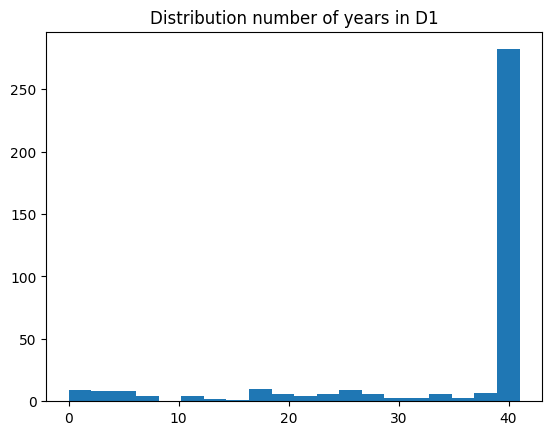

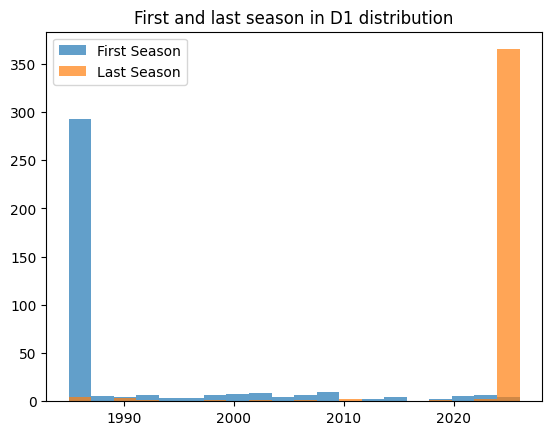

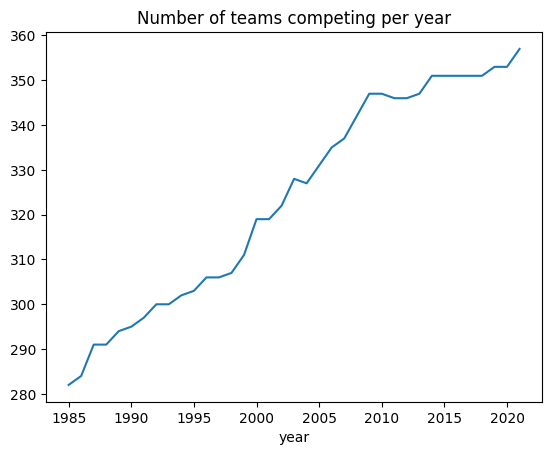

In [10]:
plot_teams('data/march-machine-learning-mania-2026/MTeams.csv')

In [11]:
plot_teams('data/march-machine-learning-mania-2026/WTeams.csv')

data/march-machine-learning-mania-2026/WTeams.csv as the following shape (379, 2)
   TeamID     TeamName
0    3101  Abilene Chr
1    3102    Air Force
2    3103        Akron
3    3104      Alabama
4    3105  Alabama A&M


# Seasons

In [12]:
[file for file in all_files if 'Seasons.csv' in file]

['data/march-machine-learning-mania-2026/MSeasons.csv',
 'data/march-machine-learning-mania-2026/WSeasons.csv']

In [13]:
df = pd.read_csv('data/march-machine-learning-mania-2026/MSeasons.csv')
print(df.shape)
df.head()

(42, 6)


,Season,DayZero,RegionW,RegionX,RegionY,RegionZ
0,1985,10/29/1984,East,West,Midwest,Southeast
1,1986,10/28/1985,East,Midwest,Southeast,West
2,1987,10/27/1986,East,Southeast,Midwest,West
3,1988,11/02/1987,East,Midwest,Southeast,West
4,1989,10/31/1988,East,West,Midwest,Southeast


In [14]:
df = pd.read_csv('data/march-machine-learning-mania-2026/WSeasons.csv')
print(df.shape)
df.head()

(29, 6)


,Season,DayZero,RegionW,RegionX,RegionY,RegionZ
0,1998,10/27/1997,East,Midwest,Mideast,West
1,1999,10/26/1998,East,Mideast,Midwest,West
2,2000,11/01/1999,East,Midwest,Mideast,West
3,2001,10/30/2000,East,Midwest,Mideast,West
4,2002,10/29/2001,East,West,Mideast,Midwest


# RegularSeasonCompactResult

In [15]:
[file for file in all_files if 'RegularSeasonCompact' in file]

['data/march-machine-learning-mania-2026/WRegularSeasonCompactResults.csv',
 'data/march-machine-learning-mania-2026/MRegularSeasonCompactResults.csv']

In [16]:
def _summariesregseason(df):
    df['point_diff'] = df.WScore - df.LScore
    summaries = df[['Season', 
                    'WScore', 
                    'LScore', 
                    'NumOT', 
                    'point_diff']].groupby('Season').agg(['min', 'max', 'mean', 'median'])

    summaries.columns = ['_'.join(col).strip() for col in summaries.columns.values]

    summaries_by = df[['Season', 'WLoc',
                'WScore', 
                'LScore', 
                'NumOT', 
                'point_diff']].groupby(['Season', 'WLoc']).agg(['min', 'max', 'mean', 'median', 'count'])

    summaries_by.columns = ['_'.join(col).strip() for col in summaries_by.columns.values]

    return df, summaries, summaries_by


def plot_regseason_compact(m_file_name, w_file_name):
    df_m = pd.read_csv(m_file_name)
    print(f"{m_file_name} as the following shape {df_m.shape}")
    print(df_m.head())
    df_w = pd.read_csv(w_file_name)
    print(f"{w_file_name} as the following shape {df_w.shape}")
    print(df_w.head())

    df_m, summary_m, summary_m_by = _summariesregseason(df_m)
    df_w, summary_w, summary_w_by = _summariesregseason(df_w)

    fig, ax = plt.subplots(1, 2, figsize=(12,5), sharex=True)
    df_m["point_diff"].hist(bins=30, ax=ax[0], grid=False)
    df_w["point_diff"].hist(bins=30, ax=ax[1], grid=False)
    ax[0].set_title("Point difference - Men")
    ax[1].set_title("Point difference - Women")
    plt.show()

    fig, ax = plt.subplots(2, 2, figsize=(12,10), sharey=True)
    summary_m[[col for col in summary_m.columns if 'WScore' in col and 'sum' not in col]].plot(title="Winning Score - Men", ax=ax[0][0])
    summary_w[[col for col in summary_w.columns if 'WScore' in col and 'sum' not in col]].plot(title="Winning Score - Women", ax=ax[0][1])

    summary_m[[col for col in summary_m.columns if 'LScore' in col and 'sum' not in col]].plot(title="Losing Score - Men", ax=ax[1][0])
    summary_w[[col for col in summary_w.columns if 'LScore' in col and 'sum' not in col]].plot(title="Losing Score - Women", ax=ax[1][1])
    plt.show()

    fig, ax = plt.subplots(2, 2, figsize=(12,10), sharey=True)
    summary_m_by[['WScore_mean']].unstack().plot(title="Winning Score by Homecourt - Men", ax=ax[0][0])
    summary_w_by[['WScore_mean']].unstack().plot(title="Winning Score by Homecourt - Women", ax=ax[0][1])

    summary_m_by[['LScore_mean']].unstack().plot(title="Losing Score by Homecourt - Men", ax=ax[1][0])
    summary_w_by[['LScore_mean']].unstack().plot(title="Losing Score by Homecourt - Women", ax=ax[1][1])
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)
    summary_m[[col for col in summary_m.columns if 'point_diff' in col and 'sum' not in col]].plot(title="Point Difference - Men", ax=ax[0])
    summary_w[[col for col in summary_w.columns if 'point_diff' in col and 'sum' not in col]].plot(title="Point Difference - Women", ax=ax[1])
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)
    summary_m_by[['point_diff_mean']].unstack().plot(title="Point Difference by Homecourt - Men", ax=ax[0])
    summary_w_by[['point_diff_mean']].unstack().plot(title="Point Difference by Homecourt - Women", ax=ax[1])
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)
    summary_m_by[['WScore_count']].unstack().plot(title="Number of Victories by Homecourt - Men", ax=ax[0])
    summary_w_by[['WScore_count']].unstack().plot(title="Number of Victories by Homecourt - Women", ax=ax[1])
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)
    summary_m[['NumOT_mean', 'NumOT_max']].plot(title="Number of Overtime - Men", ax=ax[0])
    summary_w[['NumOT_mean', 'NumOT_max']].plot(title="Number of Overtime - Women", ax=ax[1])
    plt.show()

    

data/march-machine-learning-mania-2026/MRegularSeasonCompactResults.csv as the following shape (198577, 8)
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT
0    1985      20     1228      81     1328      64    N      0
1    1985      25     1106      77     1354      70    H      0
2    1985      25     1112      63     1223      56    H      0
3    1985      25     1165      70     1432      54    H      0
4    1985      25     1192      86     1447      74    H      0
data/march-machine-learning-mania-2026/WRegularSeasonCompactResults.csv as the following shape (142507, 8)
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT
0    1998      18     3104      91     3202      41    H      0
1    1998      18     3163      87     3221      76    H      0
2    1998      18     3222      66     3261      59    H      0
3    1998      18     3307      69     3365      62    H      0
4    1998      18     3349     115     3411      35    H      0


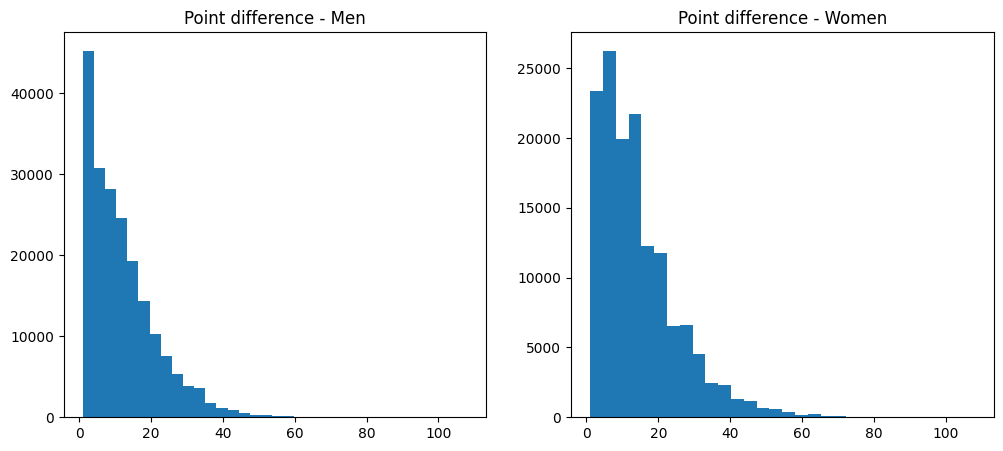

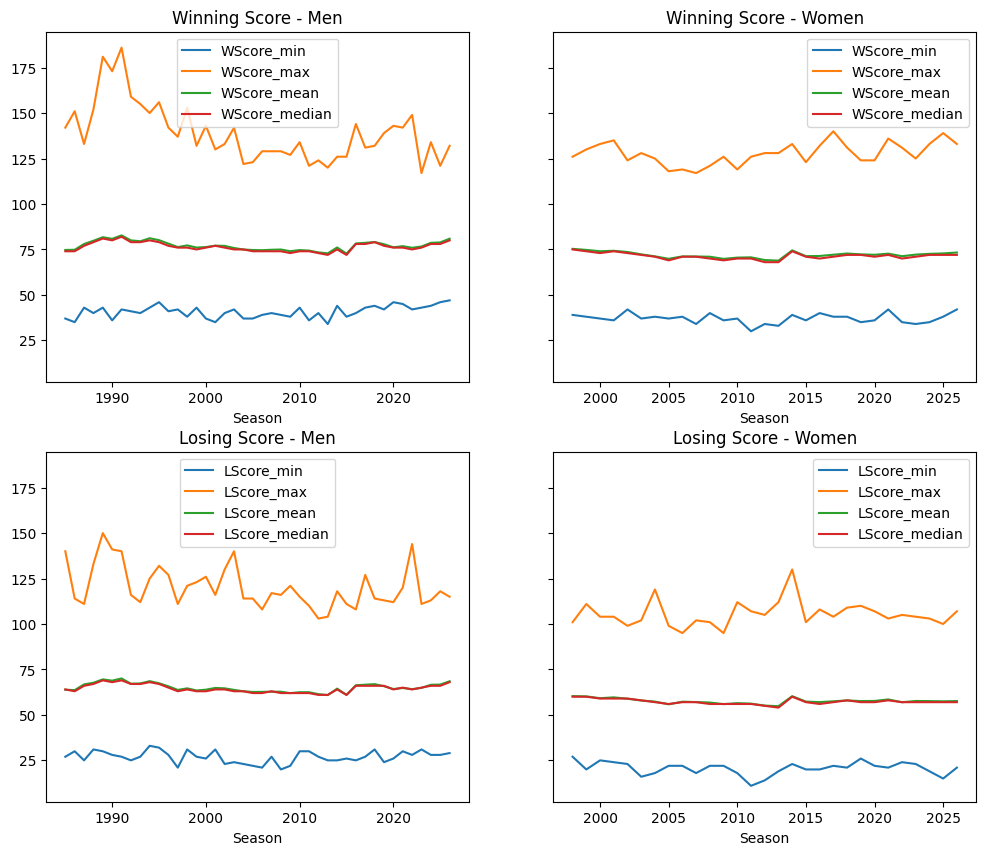

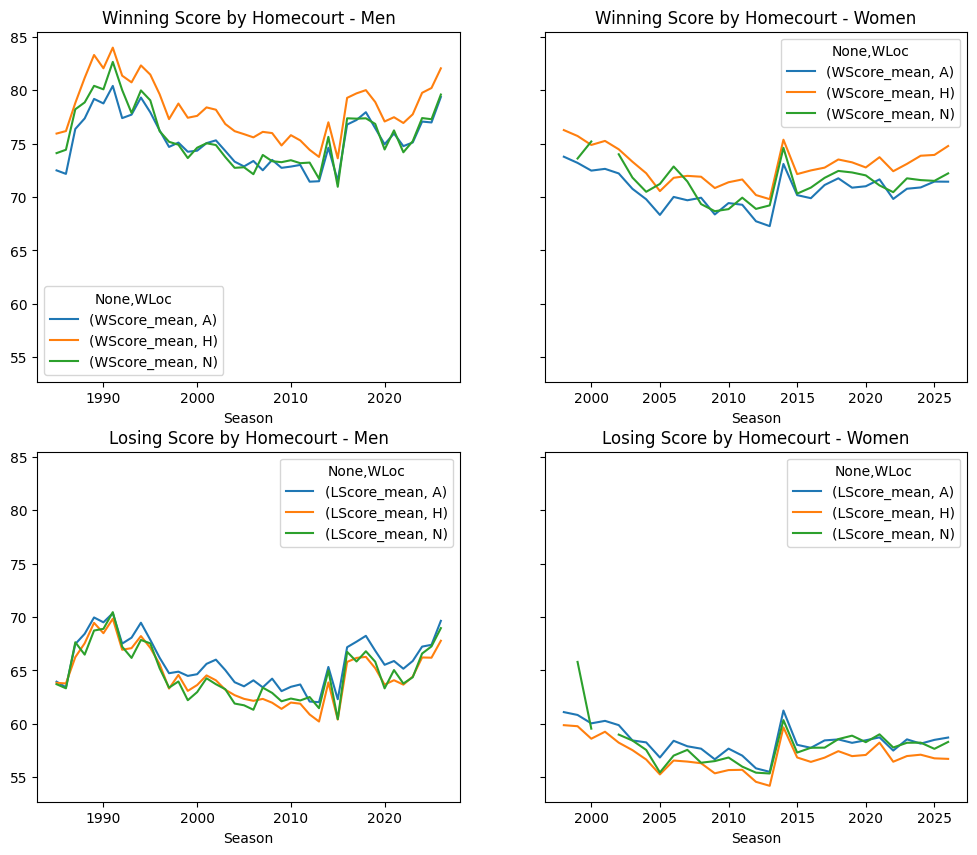

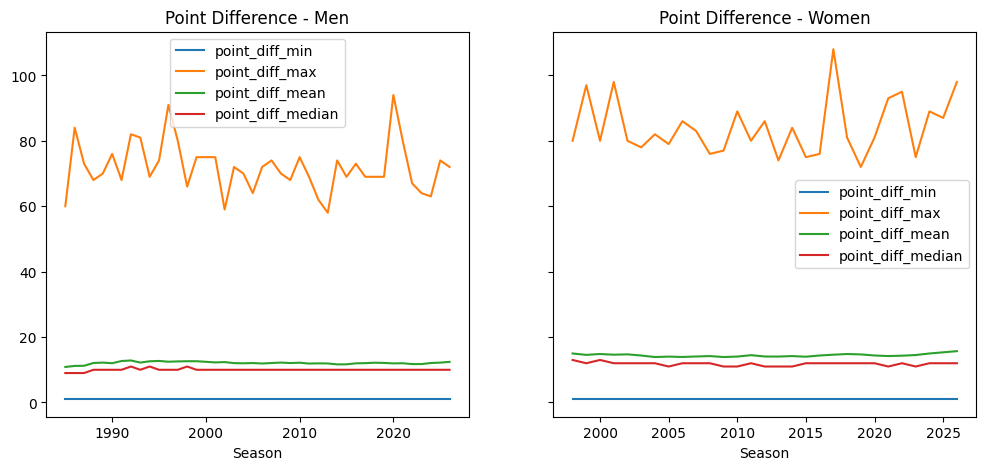

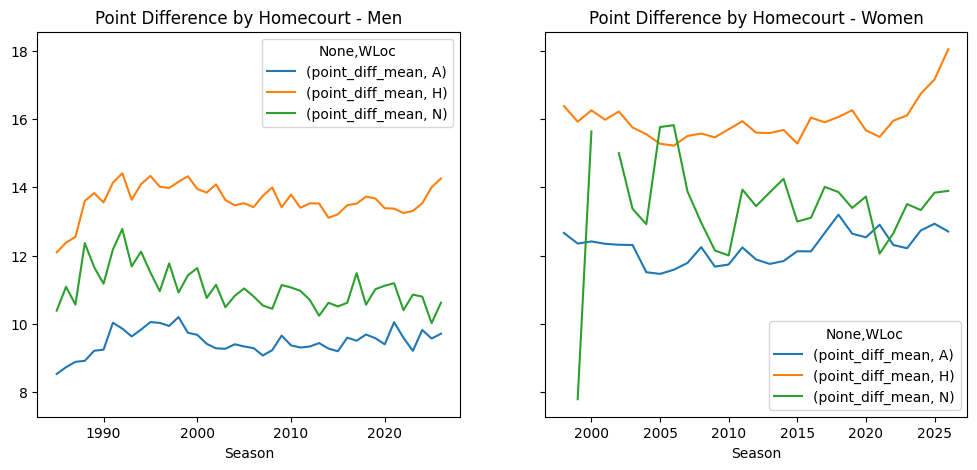

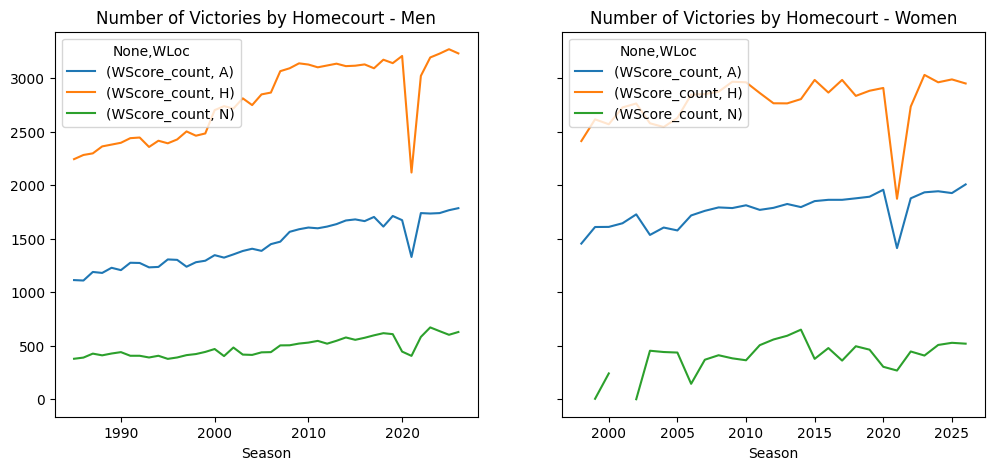

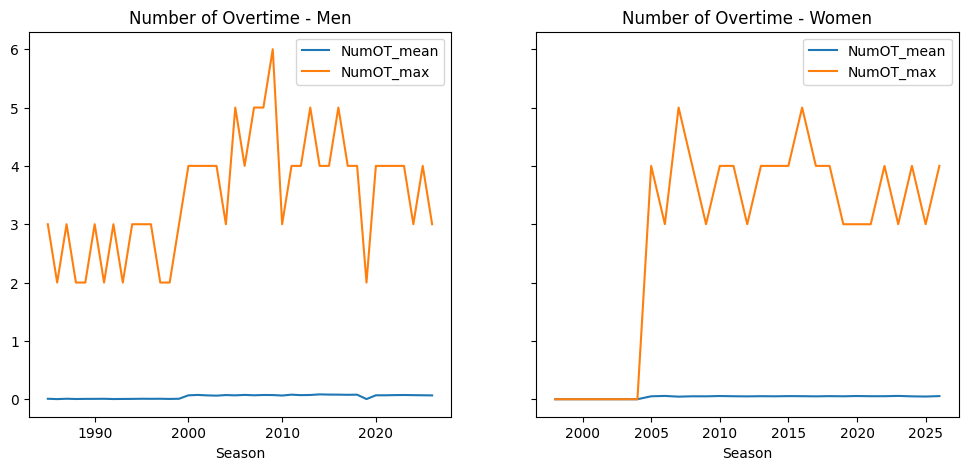

In [17]:
plot_regseason_compact(m_file_name='data/march-machine-learning-mania-2026/MRegularSeasonCompactResults.csv',
                       w_file_name='data/march-machine-learning-mania-2026/WRegularSeasonCompactResults.csv')

# Playoff Compact Result

In [18]:
[file for file in all_files if 'NCAATourneyCompact' in file]

['data/march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv',
 'data/march-machine-learning-mania-2026/WNCAATourneyCompactResults.csv']

data/march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv as the following shape (2585, 8)
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT
0    1985     136     1116      63     1234      54    N      0
1    1985     136     1120      59     1345      58    N      0
2    1985     136     1207      68     1250      43    N      0
3    1985     136     1229      58     1425      55    N      0
4    1985     136     1242      49     1325      38    N      0
data/march-machine-learning-mania-2026/WNCAATourneyCompactResults.csv as the following shape (1717, 8)
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT
0    1998     137     3104      94     3422      46    H      0
1    1998     137     3112      75     3365      63    H      0
2    1998     137     3163      93     3193      52    H      0
3    1998     137     3198      59     3266      45    H      0
4    1998     137     3203      74     3208      72    A      0


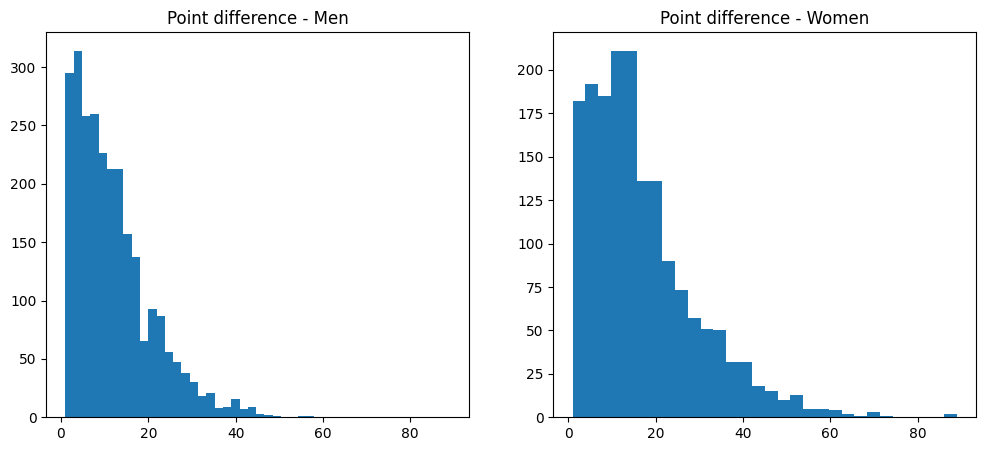

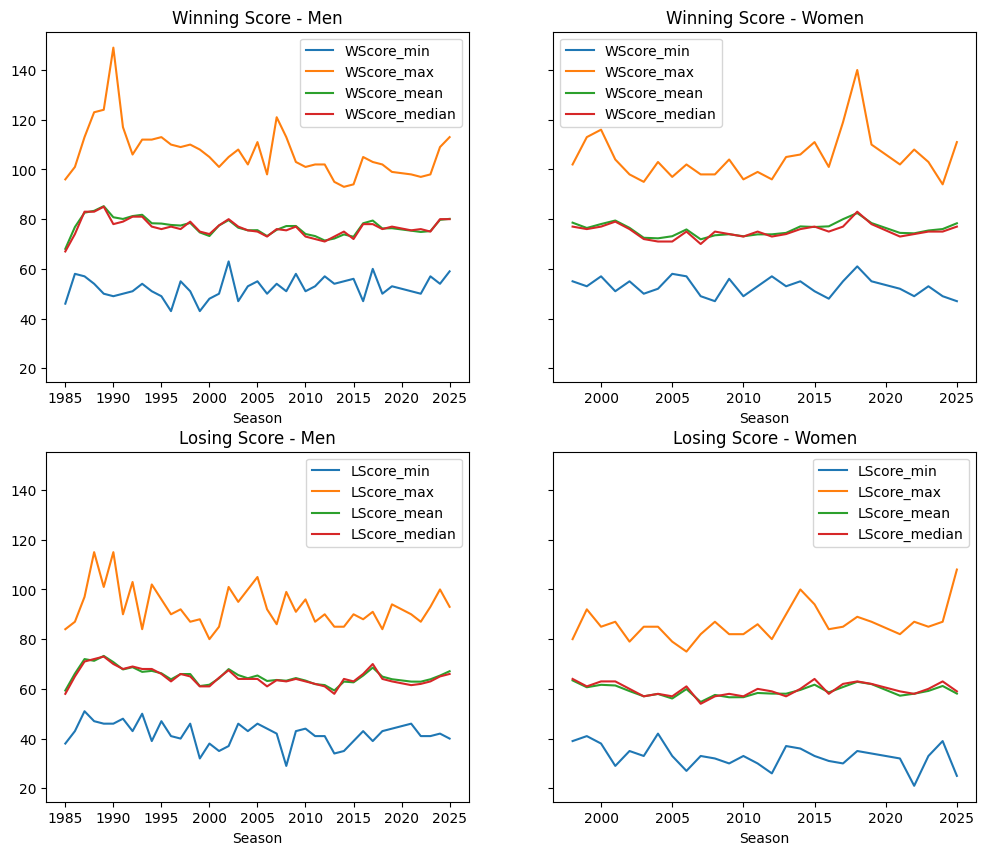

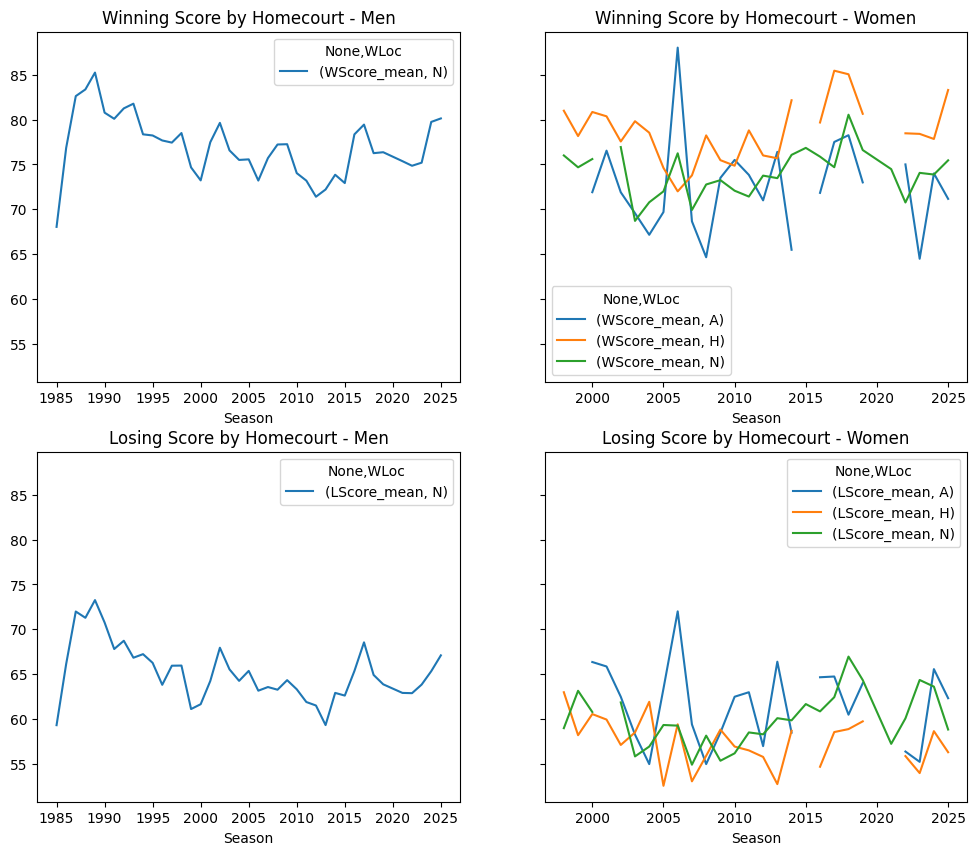

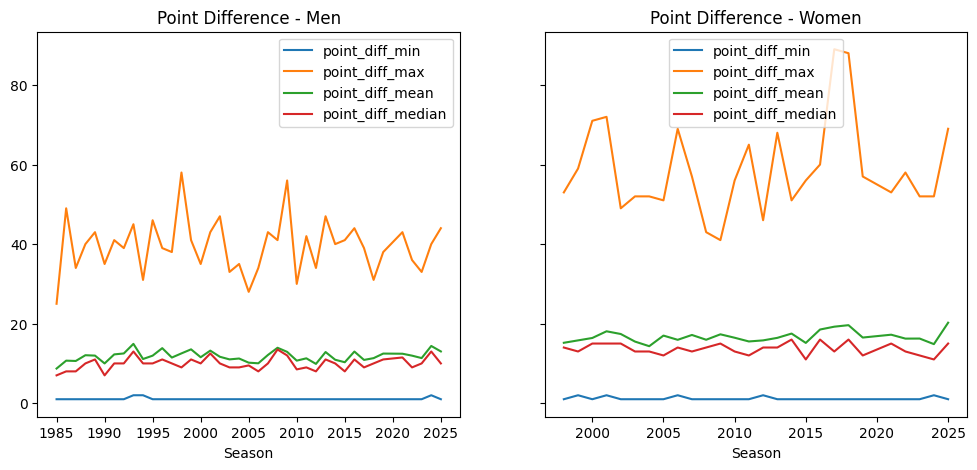

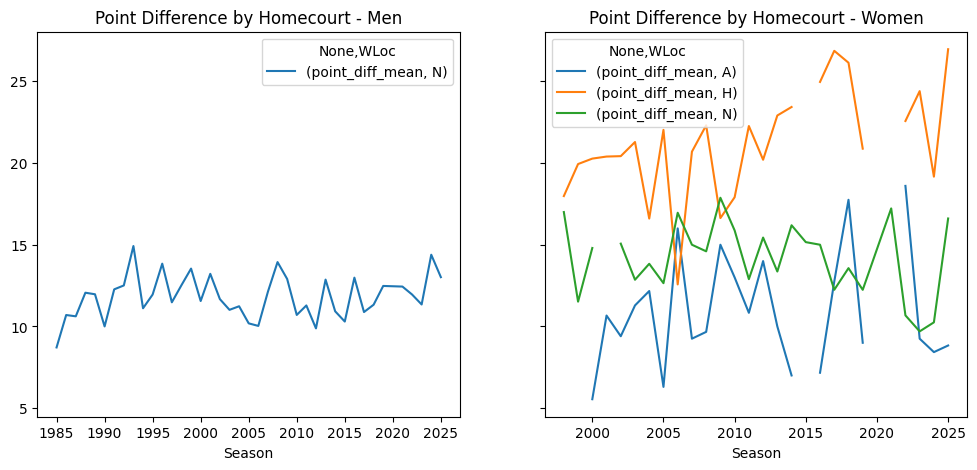

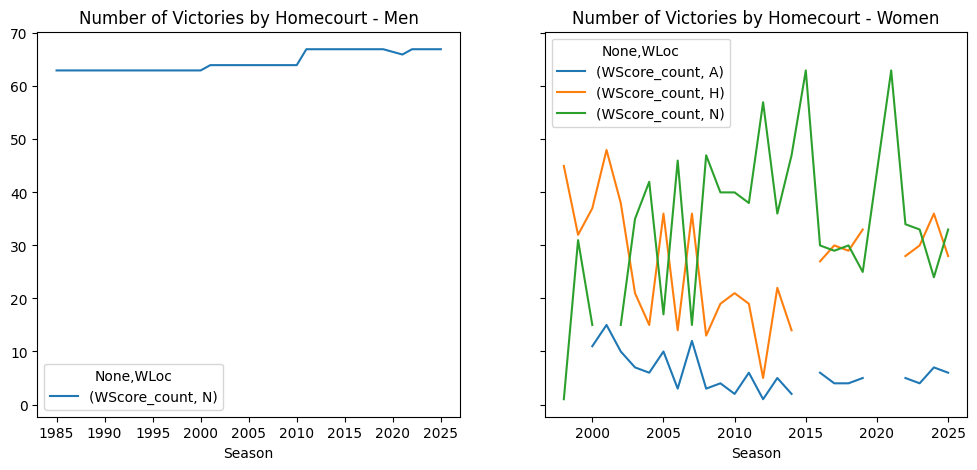

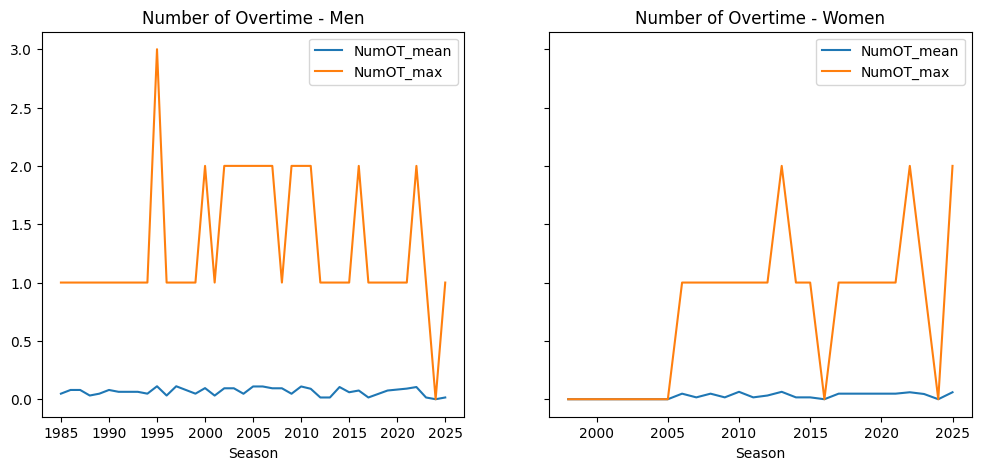

In [19]:
plot_regseason_compact(m_file_name='data/march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv',
                       w_file_name='data/march-machine-learning-mania-2026/WNCAATourneyCompactResults.csv')

# DetailedResults

In [20]:
[col for col in all_files if 'Detailed' in col]

['data/march-machine-learning-mania-2026/MRegularSeasonDetailedResults.csv',
 'data/march-machine-learning-mania-2026/MNCAATourneyDetailedResults.csv',
 'data/march-machine-learning-mania-2026/WNCAATourneyDetailedResults.csv',
 'data/march-machine-learning-mania-2026/WRegularSeasonDetailedResults.csv']

In [21]:
def _detail_summaries(df):

    not_sum = ['WTeamID', 'DayNum', 'LTeamID']
    to_sum = [col for col in df.columns if col not in not_sum]
    summaries = df[to_sum].groupby(['Season', 'WLoc']).agg(['min', 'max', 'mean', 'median', 'count'])

    summaries.columns = ['_'.join(col).strip() for col in summaries.columns.values]
    return summaries

def plot_details(m_file_name, w_file_name):
    df_m = pd.read_csv(m_file_name)
    print(f"{m_file_name} as the following shape {df_m.shape}")
    df_w = pd.read_csv(w_file_name)
    print(f"{w_file_name} as the following shape {df_w.shape}")

    stats = [col for col in df_m.columns if 'W' in col and 'ID' not in col and 'Loc' not in col]

    df_m = process_details(df_m)
    df_w = process_details(df_w)

    summary_m = _detail_summaries(df_m)
    summary_w = _detail_summaries(df_w)

    cols = [c for c in summary_m.columns if '_perc_mean' in c and c.startswith('W')]

    fig, ax= plt.subplots(len(cols),4, figsize=(25, 5*len(cols)))
    i= 0

    for col in cols:
        name = col.split('_perc_')[0][1:]
        summary_m[col].unstack().plot(title='Mean percenteage of '+name+', Winners - Men',ax=ax[i][0])
        summary_m['L'+name+'_perc_mean'].unstack().plot(title='Mean percenteage of '+name+', Losers - Men',ax=ax[i][1])
        summary_w[col].unstack().plot(title='Mean percenteage of '+name+', Winners - Women',ax=ax[i][2])
        summary_w['L'+name+'_perc_mean'].unstack().plot(title='Mean percenteage of '+name+', Losers - women',ax=ax[i][3])
        ax[i][0].legend(labels=['Away', 'Home', 'Neutral'])
        ax[i][1].legend(labels=['Away', 'Home', 'Neutral'])
        ax[i][2].legend(labels=['Away', 'Home', 'Neutral'])
        ax[i][3].legend(labels=['Away', 'Home', 'Neutral'])
        ax[i][0].set_ylim(0.2,0.8)
        ax[i][1].set_ylim(0.2,0.8)
        ax[i][2].set_ylim(0.2,0.8)
        ax[i][3].set_ylim(0.2,0.8)
        i += 1
    
    plt.show()

    fig, ax= plt.subplots(len(stats),2, figsize=(15, 5*len(stats)))

    i = 0

    for col in stats:
        name = col[1:]
        summary_m[[c for c in summary_m.columns if name+'_diff_mean' in c]].unstack().plot(title=f'Difference in mean {name} - Men',ax=ax[i][0])
        summary_w[[c for c in summary_w.columns if name+'_diff_mean' in c]].unstack().plot(title=f'Difference in mean {name} - Women',ax=ax[i][1])
        ax[i][0].legend(labels=['Away', 'Home', 'Neutral'])
        ax[i][1].legend(labels=['Away', 'Home', 'Neutral'])
        i += 1
    
    plt.show()

data/march-machine-learning-mania-2026/MRegularSeasonDetailedResults.csv as the following shape (124529, 34)
data/march-machine-learning-mania-2026/WRegularSeasonDetailedResults.csv as the following shape (87187, 34)


DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


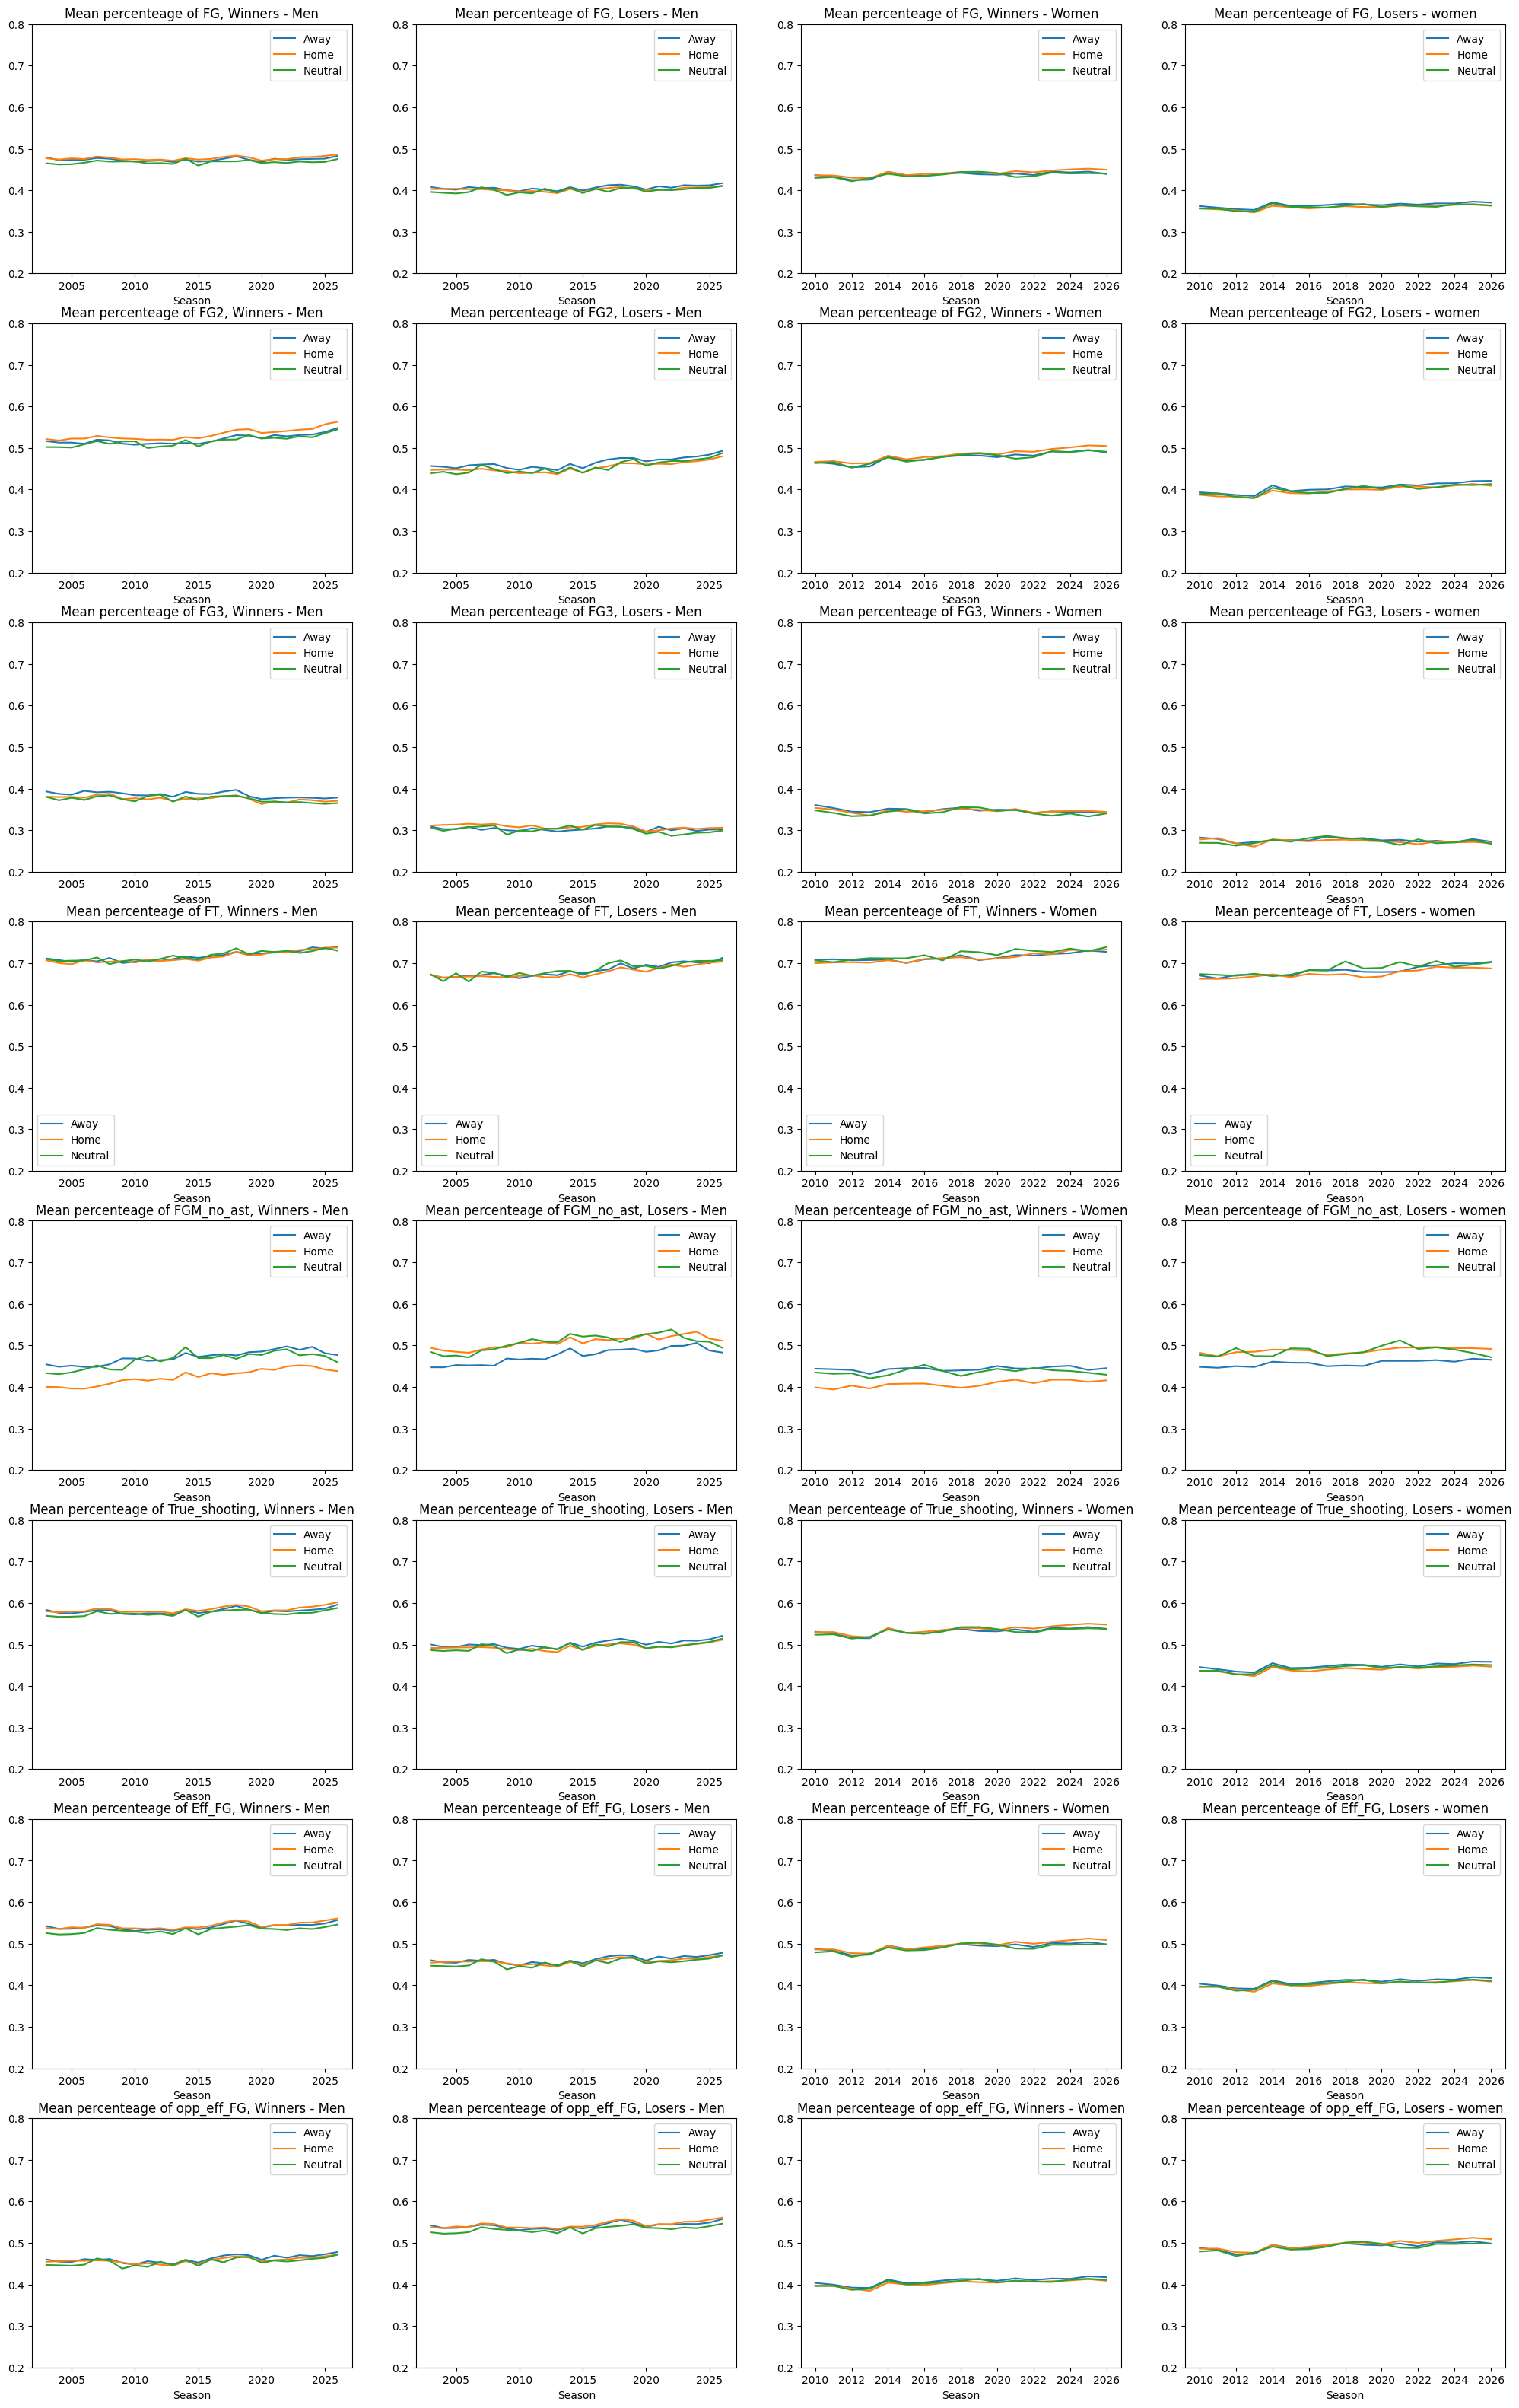

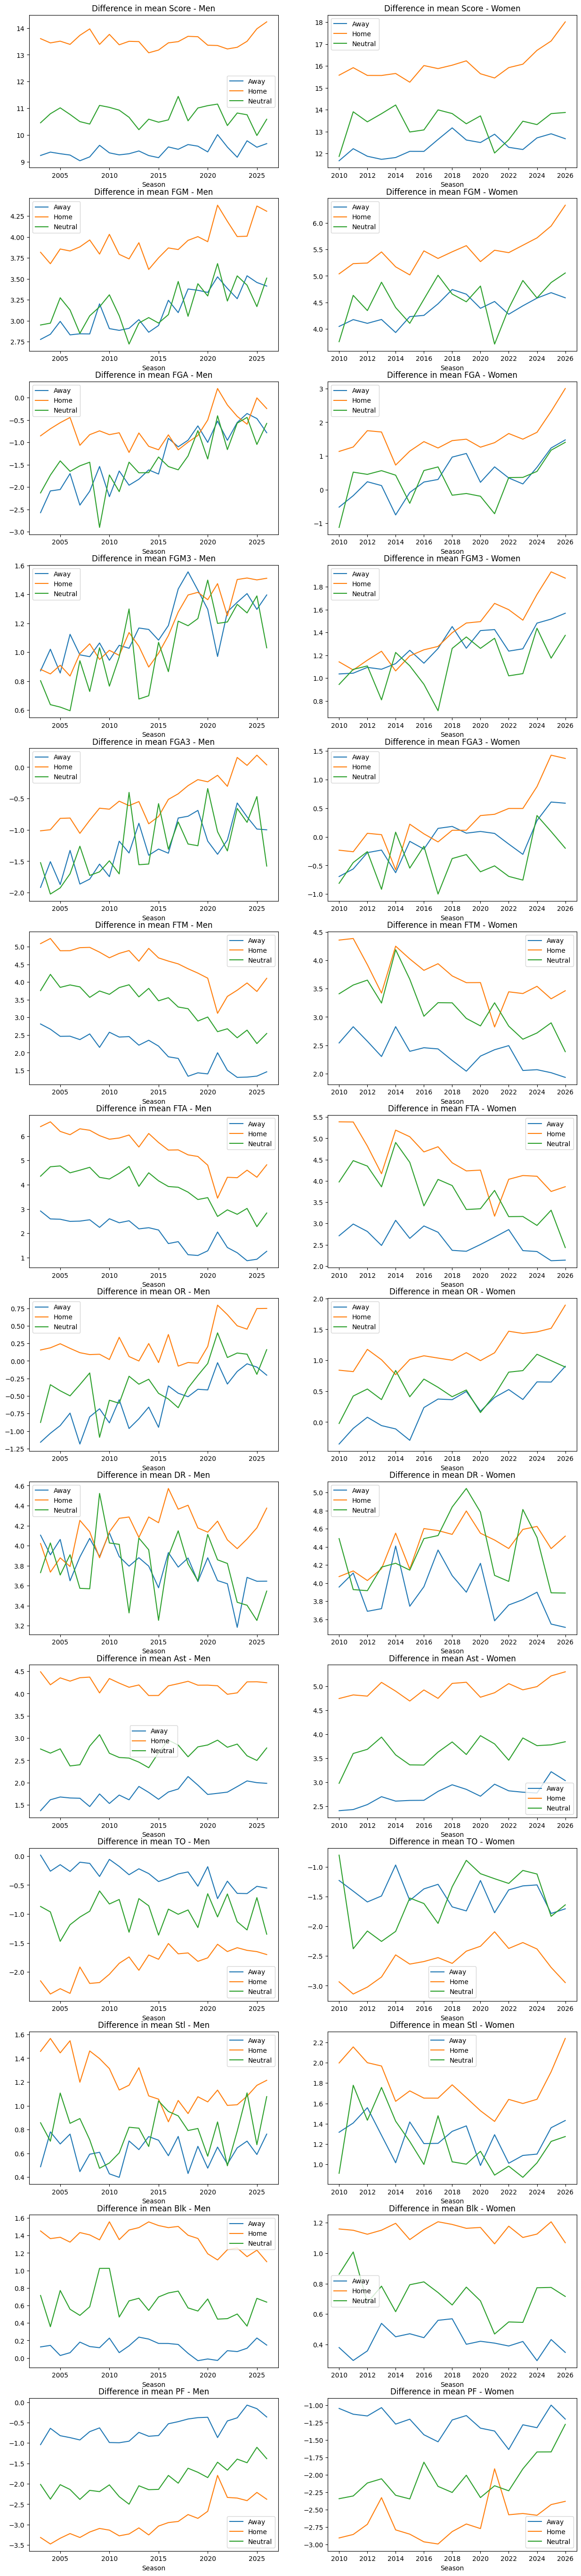

In [22]:
plot_details(m_file_name='data/march-machine-learning-mania-2026/MRegularSeasonDetailedResults.csv',
             w_file_name='data/march-machine-learning-mania-2026/WRegularSeasonDetailedResults.csv'

)

data/march-machine-learning-mania-2026/MNCAATourneyDetailedResults.csv as the following shape (1449, 34)
data/march-machine-learning-mania-2026/WNCAATourneyDetailedResults.csv as the following shape (961, 34)


DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


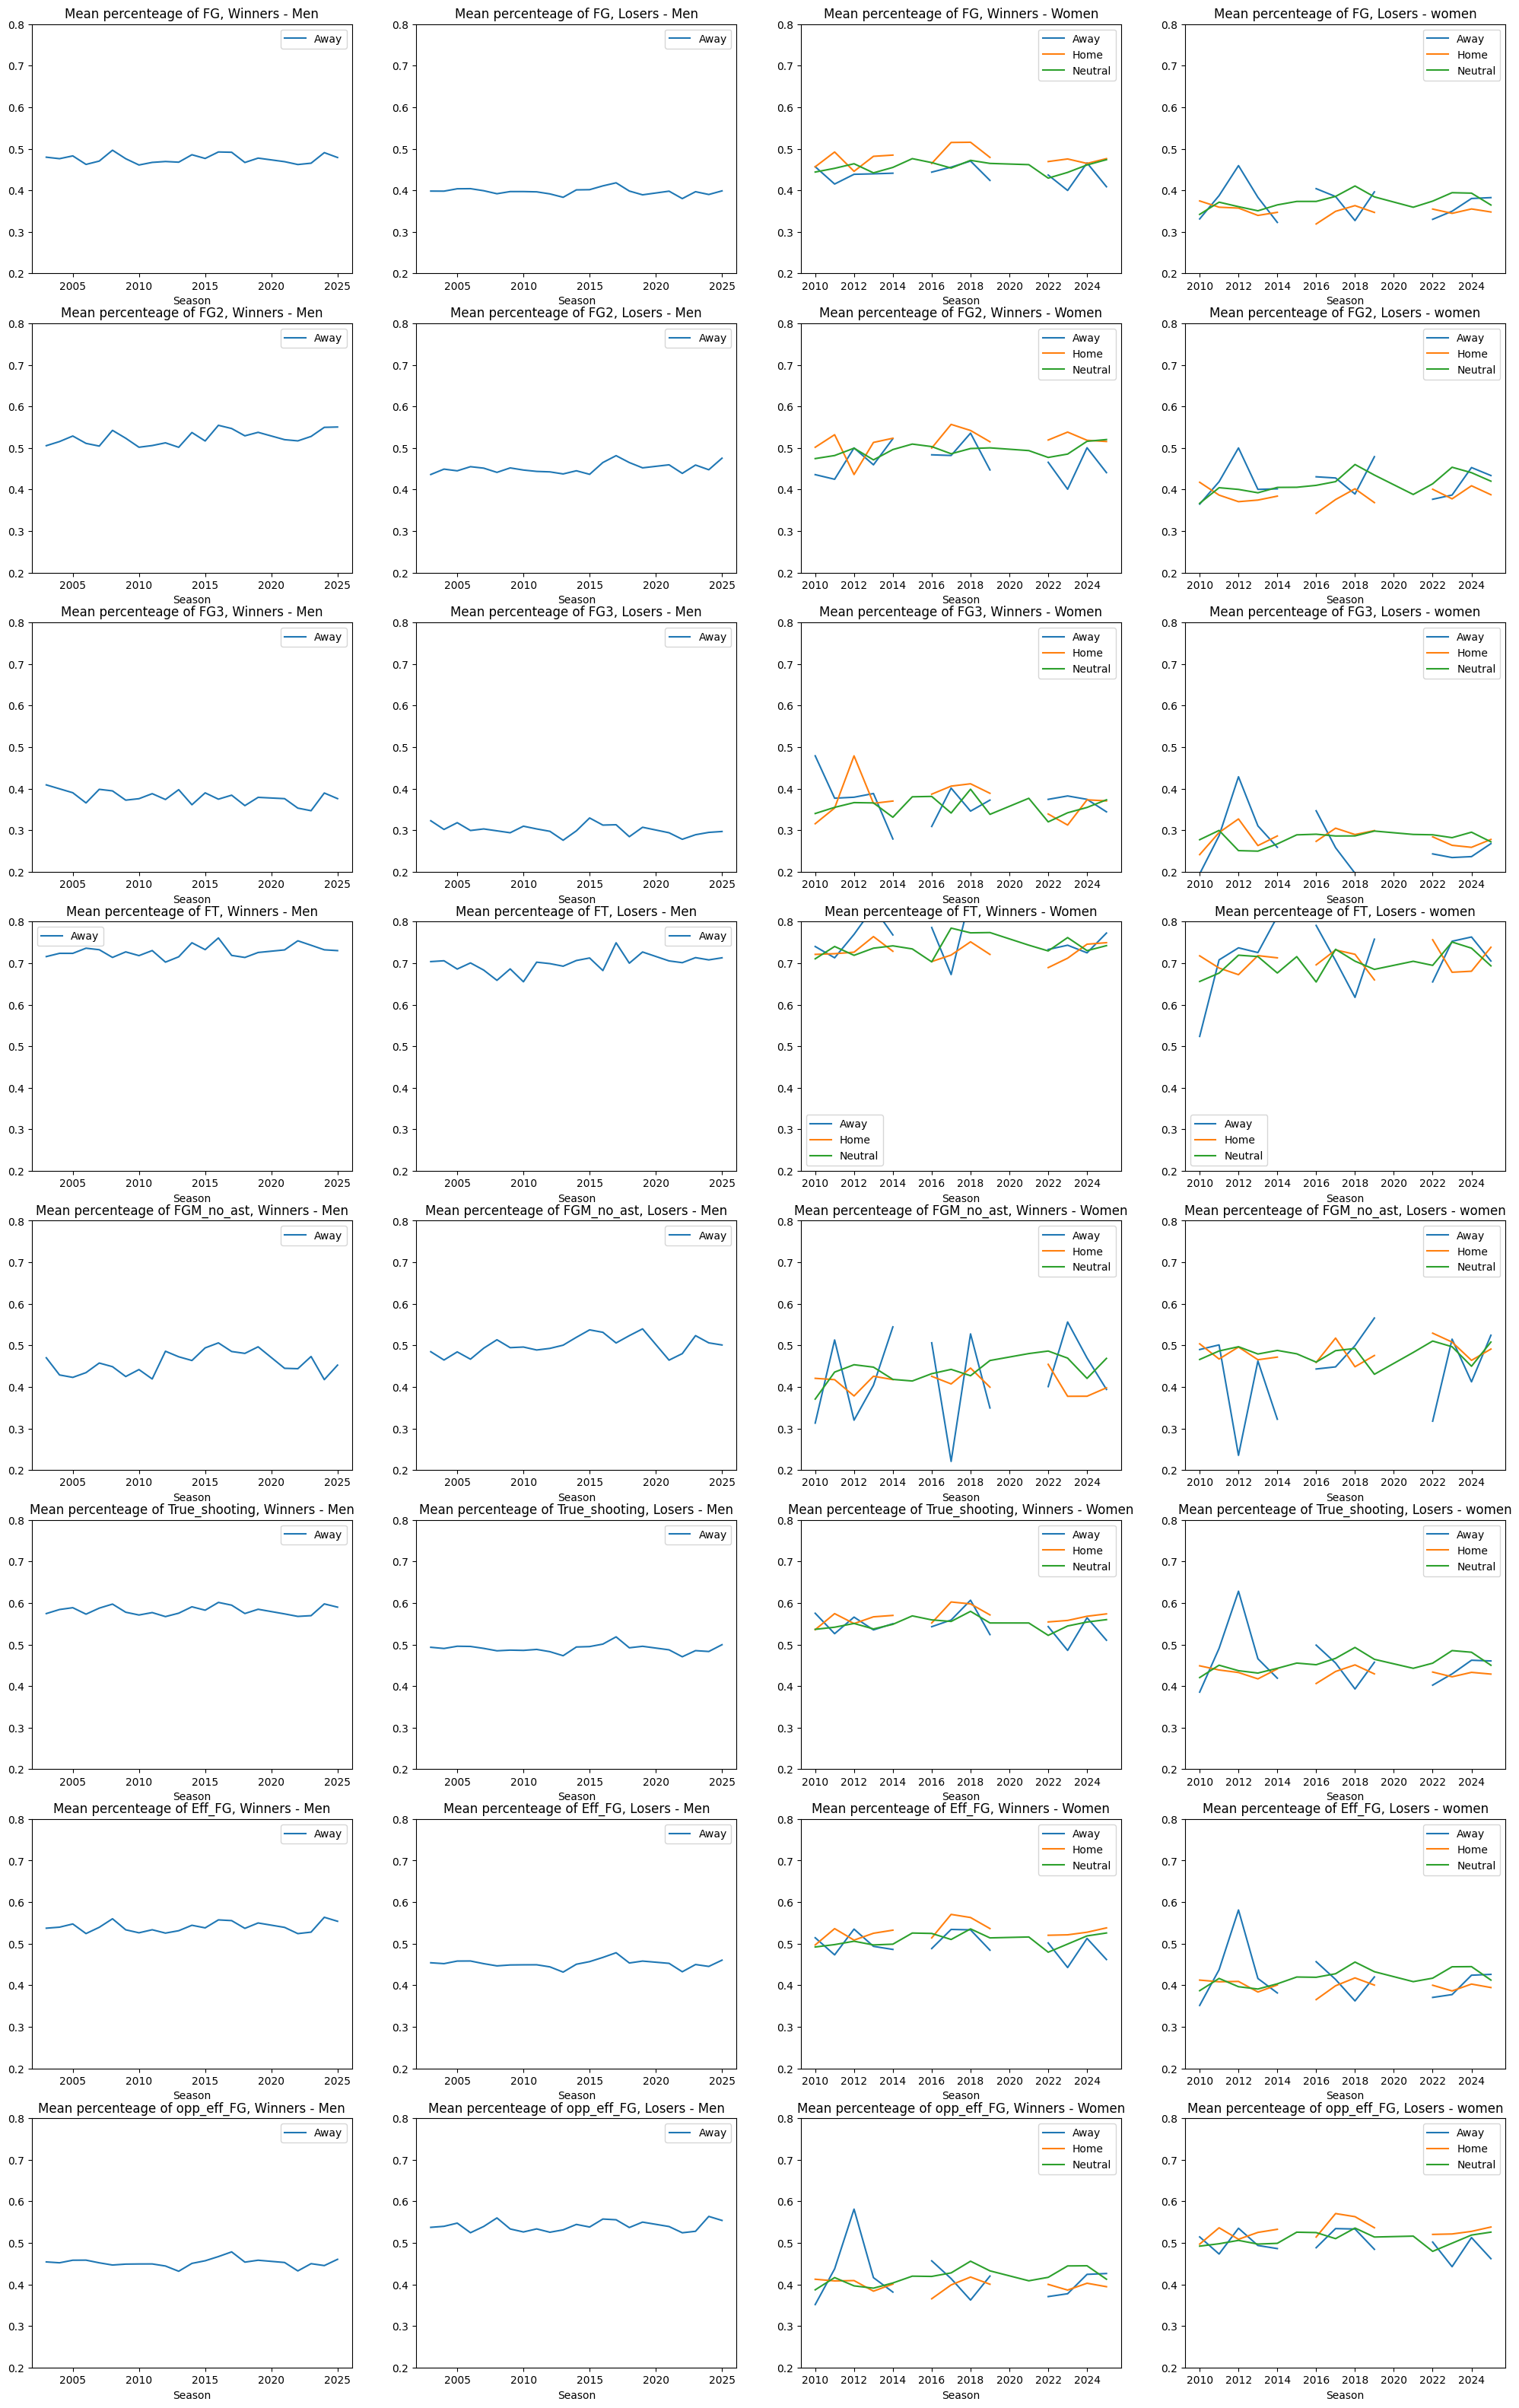

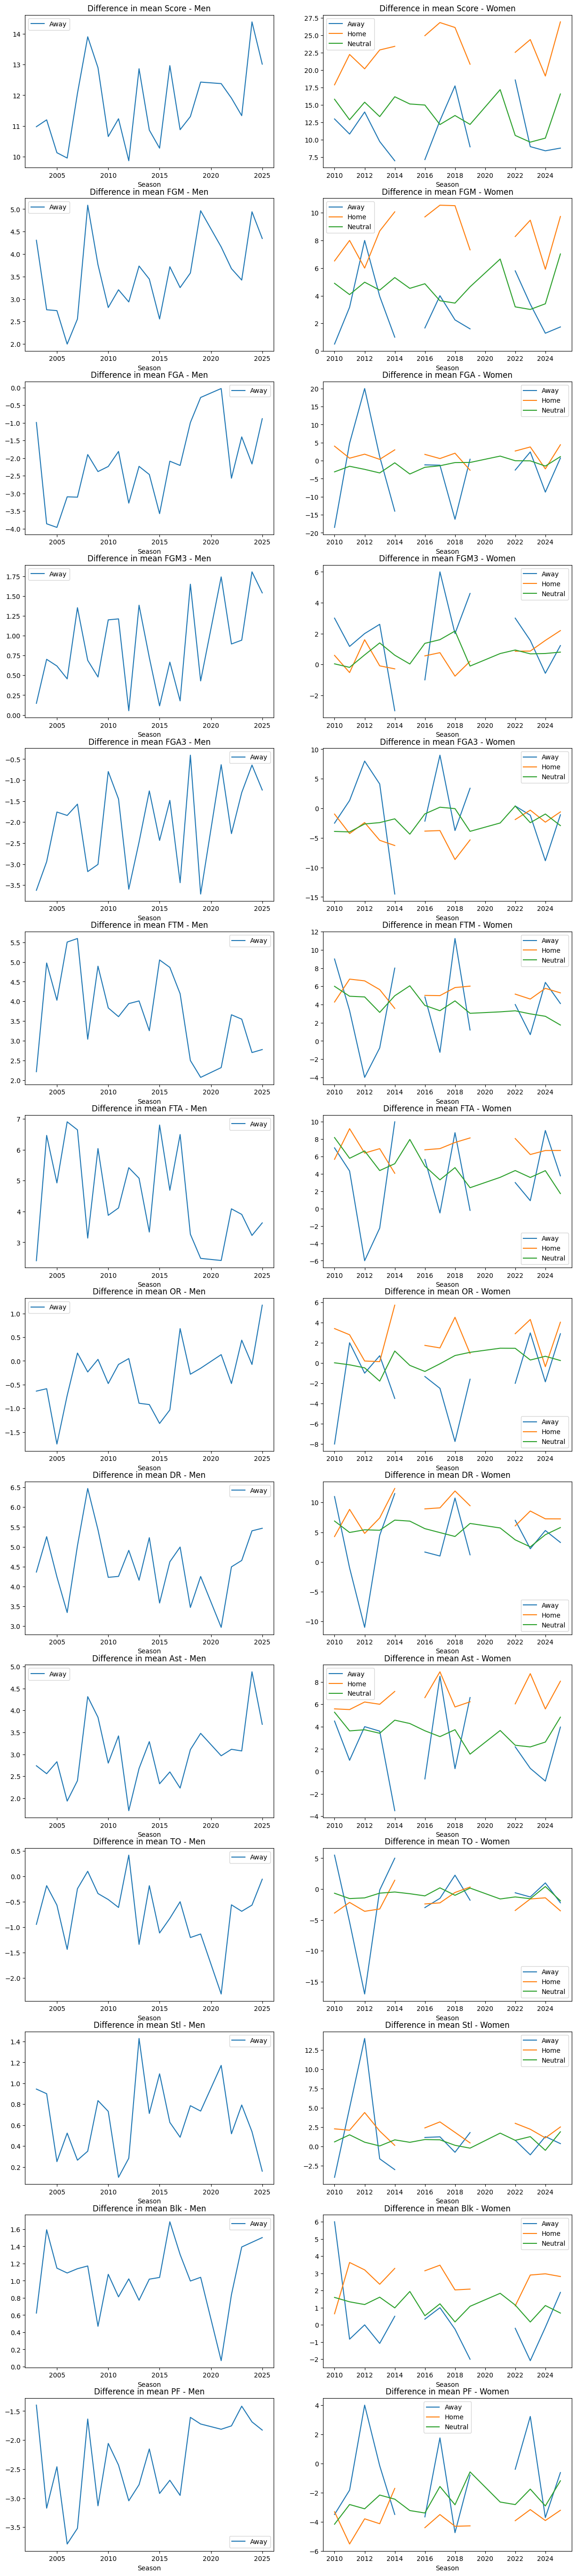

In [23]:
plot_details(m_file_name='data/march-machine-learning-mania-2026/MNCAATourneyDetailedResults.csv',
             w_file_name='data/march-machine-learning-mania-2026/WNCAATourneyDetailedResults.csv',

)

# Full Stats

In [24]:
def perc_OT_win(data):
    '''
    Creates a dataframe with the percentage of OT wins per team in a Season
    '''
    df = data[['Season', 'TeamID', 'NumOT', 'OT_win']].copy()
    df['has_OT'] = np.where(df.NumOT > 0, 1, 0)
    
    df = df.groupby(['Season', 'TeamID', 'has_OT'], as_index=False).OT_win.mean()
    df = df[df.has_OT > 0].copy()
    del df['has_OT']
    
    return df.rename(columns={'OT_win': 'OT_win_perc'})

def full_stats(data):
    '''
    Take per game details, double the dataframe to account for lost games as well,
    Add percentage of OT wins
    Create seasonal means and percentages (like shooting percentage over the season)
    '''
    df = data.copy()

    to_select = [col for col in df.columns if col.startswith('W') 
                                             and '_perc' not in col 
                                             and 'Loc' not in col]
    to_select += [col for col in df.columns if '_diff' in col or '_advantage' in col]
    df_W = df[['Season', 'DayNum', 'NumOT'] + to_select].copy()
    df_W.columns = df_W.columns.str.replace('W','')
    df_W['N_wins'] = 1

    to_select = [col for col in df.columns if col.startswith('L') 
                                             and '_perc' not in col 
                                             and 'Loc' not in col]
    to_select += [col for col in df.columns if '_diff' in col or '_advantage' in col]
    df_L = df[['Season', 'DayNum', 'NumOT'] + to_select].copy()
    df_L.columns = df_L.columns.str.replace('L','')
    df_L[[col for col in df.columns if '_diff' in col]] = - df_L[[col for col in df.columns if '_diff' in col]]
    for col in [col for col in df.columns if '_advantage' in col]:
        df_L[col] = df_L[col].map({0:1, 1:0})
    df_L['N_wins'] = 0
    df_L['OT_win'] = 0
    df_L['Away'] = 0
    if 'top_team' in df_W.columns:
        df_L['top_team'] = 0
        df_L['upset'] = 0

    df = pd.concat([df_W, df_L], sort=True)

    del df['DayNum']

    OT_perc = perc_OT_win(df)

    not_use = ['NumOT']
    to_use = [col for col in df.columns if col not in not_use]

    means = df[to_use].groupby(['Season','TeamID'], as_index=False).mean()

    sums = df[to_use].groupby(['Season','TeamID'], as_index=False).sum()
    sums['FGM_perc'] = sums.FGM / sums.FGA
    sums['FGM2_perc'] = sums.FGM2 / sums.FGA2
    sums['FGM3_perc'] = sums.FGM3 / sums.FGA3
    sums['FT_perc'] = sums.FTM / sums.FTA
    sums['FGM_no_ast_perc'] = sums.FGM_no_ast / sums.FGM
    sums['True_shooting_perc'] = 0.5 * sums['Score'] / (sums['FGA'] + 0.44 * sums['FTA'])
    sums['Opp_True_shooting_perc'] = 0.5 * sums['opp_score'] / (sums['opp_FGA'] + 0.44 * sums['opp_FTA'])
    sums["Eff_shooting_perc"] = (sums["FGM"] + 0.5*sums["FGM3"]) / sums["FGA"]
    sums["Opp_eff_shooting_perc"] = (sums["opp_FGM"] + 0.5*sums["opp_FGM3"]) / sums["opp_FGA"]

    to_use = ['Season', 'TeamID', 'FGM_perc',
              'FGM2_perc', 'FGM3_perc', 'FT_perc', 
              'FGM_no_ast_perc', 'True_shooting_perc', 'Opp_True_shooting_perc',
              "Eff_shooting_perc", "Opp_eff_shooting_perc"]

    sums = sums[to_use].fillna(0)

    stats_tot = pd.merge(means, sums, on=['Season', 'TeamID'])
    stats_tot = pd.merge(stats_tot, OT_perc, on=['Season', 'TeamID'], how='left')
    stats_tot['OT_win_perc'] = stats_tot['OT_win_perc'].fillna(0)
    
    return stats_tot

def add_seed(seed_location, total):
    '''
    Read the Seed csv and add to the Seasonal stats the seed and region
    
    seed_location: csv location
    total: Seasonal stats, it must have a TeamID and a Season column
    '''
    seed_data = pd.read_csv(seed_location)
    seed_data['region'] = seed_data['Seed'].apply(lambda x: x[0])
    seed_data['Seed'] = seed_data['Seed'].apply(lambda x: int(x[1:3]))
    total = pd.merge(total, seed_data, how='left', on=['TeamID', 'Season'])
    return total

In [25]:
[f for f in all_files if "Seed" in f]

['data/march-machine-learning-mania-2026/WNCAATourneySeeds.csv',
 'data/march-machine-learning-mania-2026/MNCAATourneySeeds.csv',
 'data/march-machine-learning-mania-2026/MNCAATourneySeedRoundSlots.csv']

In [35]:
df = pd.read_csv('data/march-machine-learning-mania-2026/MRegularSeasonDetailedResults.csv')
df = process_details(df)
df = full_stats(df)
df = add_seed('data/march-machine-learning-mania-2026/MNCAATourneySeeds.csv', df)

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


In [36]:
df.head()

,Season,TeamID,Ast,Ast_TO_ratio,Ast_TO_ratio_diff,Ast_diff,Away,Blk,Blk_diff,DR,DR_diff,DR_opportunity,DR_opportunity_diff,Eff_FG_perc_diff,FG3_ratio,FG3_ratio_diff,FGA,FGA2,FGA2_diff,FGA3,FGA3_diff,FGA_diff,FGM,FGM2,FGM2_diff,FGM3,FGM3_diff,FGM_diff,FGM_no_ast,FGM_no_ast_diff,FTA,FTA_diff,FTM,FTM_diff,N_wins,OR,OR_diff,OR_opportunity,OR_opportunity_diff,OT_win,PF,PF_diff,Score,Score_diff,Stl,Stl_diff,TO,TO_diff,TO_perposs,TO_perposs_diff,Tot_Reb,Tot_Reb_diff,True_shooting_perc_diff,def_rating,def_rating_diff,impact,impact_diff,off_rating,off_rating_diff,opp_FGA,opp_FGM,opp_FGM3,opp_FTA,opp_PF,opp_TO,opp_possessions,opp_score,opp_shtg_opportunity,possessions,possessions_diff,shtg_opportunity,shtg_opportunity_diff,FGM_perc,FGM2_perc,FGM3_perc,FT_perc,FGM_no_ast_perc,True_shooting_perc,Opp_True_shooting_perc,Eff_shooting_perc,Opp_eff_shooting_perc,OT_win_perc,Seed,region
0,2003,1102,13.000000,1.375047,0.605180,3.857143,0.107143,1.785714,0.214286,16.821429,-3.321429,0.729546,-0.269979,0.070266,1.250582,0.814344,39.785714,18.964286,-11.035714,20.821429,8.392857,-2.642857,19.142857,11.321429,-3.214286,7.821429,3.071429,-0.142857,6.142857,-4.000000,17.107143,-2.142857,11.142857,-2.535714,0.428571,4.178571,-5.428571,0.199280,-0.220372,0.000000,18.750000,0.392857,57.250000,0.250000,5.964286,0.535714,11.428571,-1.535714,0.207292,-0.032061,21.000000,-8.750000,0.043781,105.142005,0.239386,0.487043,-0.025913,104.902619,-0.239386,42.428571,19.285714,4.750000,19.250000,18.357143,12.964286,54.255714,57.000000,0.937798,54.562857,0.307143,0.870175,-0.067623,0.481149,0.596987,0.375643,0.651357,0.320896,0.605015,0.559937,0.579443,0.510522,0.00,NaN,NaN
1,2003,1103,14.723457,1.324471,0.263213,-0.184362,0.148148,2.297119,-0.453498,19.255967,-1.976955,0.684811,-0.091868,-0.012534,0.436301,-0.061005,54.051029,38.439506,1.172840,15.611523,-2.130041,-0.957202,26.268313,20.972016,0.603292,5.296296,-1.129218,-0.525926,11.544856,-0.341564,24.580247,3.511111,18.134979,2.889712,0.481481,9.497119,-1.946502,0.338522,-0.071823,0.111111,19.027160,-2.539095,75.967901,0.708642,6.886420,0.667490,12.287243,-2.466667,0.181539,-0.036284,28.753086,-3.923457,-0.003423,111.829472,-0.155601,0.498574,-0.002852,111.985073,0.155601,55.008230,26.794239,6.425514,21.069136,21.566255,14.753909,67.588938,75.259259,0.952803,67.656461,0.067523,0.958162,0.005358,0.485991,0.545585,0.339256,0.737787,0.439497,0.585573,0.585414,0.534984,0.545500,0.75,NaN,NaN
2,2003,1104,12.059524,0.992381,0.044656,0.420635,0.142857,3.777778,0.607143,23.853175,1.301587,0.745133,0.052238,-0.004314,0.539779,-0.013489,56.964286,37.158730,0.928571,19.805556,0.738095,1.666667,23.940476,17.611111,0.805556,6.329365,-0.015873,0.789683,11.880952,0.369048,20.849206,3.753968,14.805556,2.698413,0.607143,13.523810,2.666667,0.406872,0.066526,0.035714,17.972222,-1.198413,69.015873,4.261905,6.571429,1.067460,13.234127,-0.555556,0.201266,-0.007759,37.376984,3.968254,0.003381,98.975644,-5.552004,0.527160,0.054319,104.527648,5.552004,55.297619,23.150794,6.345238,17.095238,19.170635,13.789683,65.752063,64.753968,0.955673,65.848254,0.096190,1.003713,0.048041,0.420272,0.473943,0.319575,0.710126,0.496271,0.521757,0.515397,0.475827,0.476032,1.00,10.0,Y
3,2003,1105,14.269231,0.861951,-0.074315,-1.292308,0.076923,2.033333,-2.105128,22.625641,-3.300000,0.728313,0.015613,-0.051325,0.544292,0.103240,60.519658,40.146154,-0.490598,20.373504,3.163248,2.672650,23.938462,16.491453,-3.933333,7.447009,1.323077,-2.610256,9.669231,-1.317949,21.348718,-2.546154,15.076923,-0.946154,0.269231,13.252137,0.350427,0.361851,-0.047139,0.000000,19.789744,1.105983,70.400855,-4.843590,9.128205,-0.089744,18.272650,-0.212821,0.243300,-0.005511,35.877778,-2.949573,-0.045818,102.129410,8.187222,0.444964,-0.110071,93.942187,-8.187222,57.847009,26.548718,6.123932,23.894872,18.683761,18.485470,73.944513,75.244444,0.926956,74.933607,0.989094,0.933929,0.006973,0.395549,0.410785,0.365524,0.706221,0.403920,0.503488,0.550348,0.457074,0.511879,0.00,NaN,NaN
4,2003,1

In [38]:
df[df["Season"] == 2026]

,Season,TeamID,Ast,Ast_TO_ratio,Ast_TO_ratio_diff,Ast_diff,Away,Blk,Blk_diff,DR,DR_diff,DR_opportunity,DR_opportunity_diff,Eff_FG_perc_diff,FG3_ratio,FG3_ratio_diff,FGA,FGA2,FGA2_diff,FGA3,FGA3_diff,FGA_diff,FGM,FGM2,FGM2_diff,FGM3,FGM3_diff,FGM_diff,FGM_no_ast,FGM_no_ast_diff,FTA,FTA_diff,FTM,FTM_diff,N_wins,OR,OR_diff,OR_opportunity,OR_opportunity_diff,OT_win,PF,PF_diff,Score,Score_diff,Stl,Stl_diff,TO,TO_diff,TO_perposs,TO_perposs_diff,Tot_Reb,Tot_Reb_diff,True_shooting_perc_diff,def_rating,def_rating_diff,impact,impact_diff,off_rating,off_rating_diff,opp_FGA,opp_FGM,opp_FGM3,opp_FTA,opp_PF,opp_TO,opp_possessions,opp_score,opp_shtg_opportunity,possessions,possessions_diff,shtg_opportunity,shtg_opportunity_diff,FGM_perc,FGM2_perc,FGM3_perc,FT_perc,FGM_no_ast_perc,True_shooting_perc,Opp_True_shooting_perc,Eff_shooting_perc,Opp_eff_shooting_perc,OT_win_perc,Seed,region
7981,2026,1101,12.492593,1.042805,0.176316,0.081481,0.166667,2.562963,-2.044444,18.203704,-3.707407,0.767340,0.061421,-0.088896,0.507853,0.051475,54.403704,36.540741,2.514815,17.862963,3.307407,5.822222,23.081481,17.522222,-0.988889,5.559259,-0.396296,-1.385185,10.588889,-1.466667,22.674074,-3.262963,15.981481,-2.755556,0.366667,8.318519,1.859259,0.264178,-0.003942,0.000000,21.237037,2.751852,67.703704,-5.922222,9.551852,1.074074,13.466667,-1.929630,0.192814,-0.030027,26.522222,-1.848148,-0.088091,106.653868,9.122888,0.429767,-0.140466,97.530980,-9.122888,48.581481,24.466667,5.955556,25.937037,18.485185,15.396296,68.930815,73.625926,0.871241,69.528444,0.597630,0.927648,0.056406,0.424263,0.479526,0.311217,0.704835,0.458761,0.525811,0.613613,0.475356,0.564916,0.0,NaN,NaN
7982,2026,1102,12.156250,0.956706,-0.897732,-3.093750,0.000000,2.375000,-1.156250,20.531250,-3.718750,0.709484,-0.122939,-0.073254,0.756631,0.079197,51.156250,29.781250,-5.281250,21.375000,-0.875000,-6.156250,21.750000,15.218750,-4.531250,6.531250,-1.843750,-6.375000,9.593750,-3.281250,17.937500,-3.031250,11.500000,-3.750000,0.093750,5.812500,-2.843750,0.199851,-0.092978,0.000000,17.812500,0.031250,61.531250,-18.343750,5.625000,-2.343750,13.437500,3.625000,0.201411,0.057679,26.343750,-6.562500,-0.079739,118.304488,25.909886,0.383908,-0.232184,92.394602,-25.909886,57.312500,28.125000,8.375000,20.968750,17.781250,9.812500,67.695000,79.875000,0.983913,66.673750,-1.021250,0.886081,-0.097832,0.425168,0.511018,0.305556,0.641115,0.441092,0.521021,0.600214,0.489004,0.563795,0.0,NaN,NaN
7983,2026,1103,17.875000,1.862385,0.687434,4.656250,0.437500,2.875000,0.031250,24.656250,4.937500,0.718900,0.092024,0.077677,0.881020,0.081442,62.593750,34.343750,-0.031250,28.250000,2.062500,2.031250,31.156250,20.281250,3.437500,10.875000,1.687500,5.125000,13.281250,0.468750,18.187500,-0.156250,13.687500,0.437500,0.843750,9.562500,0.187500,0.304315,0.039165,0.000000,16.281250,0.187500,86.875000,12.375000,7.250000,0.968750,10.531250,-1.843750,0.147255,-0.024882,34.218750,5.125000,0.070873,104.138318,-17.245336,0.589251,0.178502,121.383654,17.245336,60.562500,26.031250,9.187500,18.343750,16.093750,12.375000,71.633750,74.500000,0.958485,71.565000,-0.068750,0.987520,0.029035,0.497753,0.590537,0.384956,0.752577,0.426279,0.615295,0.542736,0.584623,0.505676,0.0,12.0,Y
7984,2026,1104,16.025000,1.956380,-0.006656,2.181250,0.343750,5.056250,1.406250,26.506250,2.106250,0.687767,-0.000684,0.062113,1.262785,0.688323,65.431250,30.268750,-14.100000,35.162500,11.168750,-2.931250,29.906250,17.312500,-4.250000,12.593750,4.581250,0.331250,13.881250,-1.850000,24.287500,1.906250,18.581250,2.993750,0.718750,10.118750,-1.487500,0.283189,-0.013434,0.031250,18.425000,-1.256250,90.987500,8.237500,6.406250,0.037500,9.368750,0.131250,0.123817,0.002304,36.625000,0.618750,0.069709,109.252646,-11.542458,0.556086,0.112172,120.795104,11.542458,68.362500,29.575000,8.012500,22.381250,19.681250,9.237500,75.841500,82.750000,1.033546,75.367750,-0.473750,1.010428,-0.023118,0.457064,0.571960,0.358159,0.765054,0.464159,0.597676,0.529023,0.553300,0.491223,1.0,4.0,

In [30]:
[c for c in df if "impact" in c]

['impact', 'impact_diff']